# Exploratory Data Analysis (EDA)

In this notebook, we explore the cleaned Spotify tracks dataset to understand its characteristics, identify relationships between variables, and generate visualizations that will guide later modeling.

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os

In [ ]:
os.makedirs("../reports/figures", exist_ok=True)

In [ ]:
df = pd.read_csv("../data/processed/cleaned_dataset_full.csv")

In [ ]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,0,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,0,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 89740 entries, 0 to 89739
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        89740 non-null  int64  
 1   track_id          89740 non-null  str    
 2   artists           89740 non-null  str    
 3   album_name        89740 non-null  str    
 4   track_name        89740 non-null  str    
 5   popularity        89740 non-null  int64  
 6   duration_ms       89740 non-null  int64  
 7   explicit          89740 non-null  int64  
 8   danceability      89740 non-null  float64
 9   energy            89740 non-null  float64
 10  key               89740 non-null  int64  
 11  loudness          89740 non-null  float64
 12  mode              89740 non-null  int64  
 13  speechiness       89740 non-null  float64
 14  acousticness      89740 non-null  float64
 15  instrumentalness  89740 non-null  float64
 16  liveness          89740 non-null  float64
 17  vale

In [ ]:
df.describe()

,Unnamed: 0,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,89740.000000,89740.000000,8.974000e+04,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000,89740.000000
mean,53479.005739,33.198808,2.291444e+05,0.085848,0.562166,0.634458,5.283530,-8.498994,0.636973,0.087442,0.328285,0.173415,0.216971,0.469474,122.058134,3.897426
std,33410.141924,20.580640,1.129458e+05,0.280141,0.176692,0.256606,3.559912,5.221518,0.480875,0.113278,0.338321,0.323849,0.194885,0.262864,30.117651,0.453437
min,0.000000,0.000000,8.586000e+03,0.000000,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23766.750000,19.000000,1.730400e+05,0.000000,0.450000,0.457000,2.000000,-10.322250,0.000000,0.036000,0.017100,0.000000,0.098200,0.249000,99.262750,4.000000
50%,50680.500000,33.000000,2.132955e+05,0.000000,0.576000,0.676000,5.000000,-7.185000,1.000000,0.048900,0.188000,0.000058,0.132000,0.457000,122.013000,4.000000
75%,80618.500000,49.000000,2.642930e+05,0.000000,0.692000,0.853000,8.000000,-5.108000,1.000000,0.085900,0.625000,0.097625,0.279000,0.682000,140.077000,4.000000
max,113999.000000,100.000000,5.237295e+06,1.000000,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## Dataset Overview

The cleaned Spotify dataset contains information about tracks, including their popularity, genre, and multiple audio characteristics such as danceability, energy, loudness, acousticness, and tempo. Before building predictive models, it is important to understand the distributions and relationships among these variables.

## 1. Distribution of Track Popularity

This visualization shows how popularity scores are distributed across all tracks in the dataset.

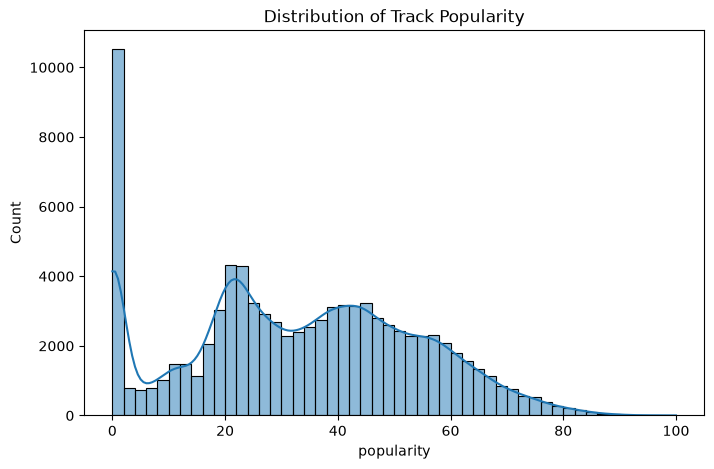

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["popularity"],
             bins=50,
             kde=True)

plt.title("Distribution of Track Popularity")

plt.savefig(
    "../reports/figures/popularity_dist.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Observation

- The popularity distribution is highly right-skewed.
- A large number of songs have very low popularity, while relatively few tracks achieve high popularity.
- This suggests that popularity is not evenly distributed and may be difficult to predict using simple linear models.

## 2. Correlation Between Audio Features

A correlation heatmap helps identify relationships between numerical variables.


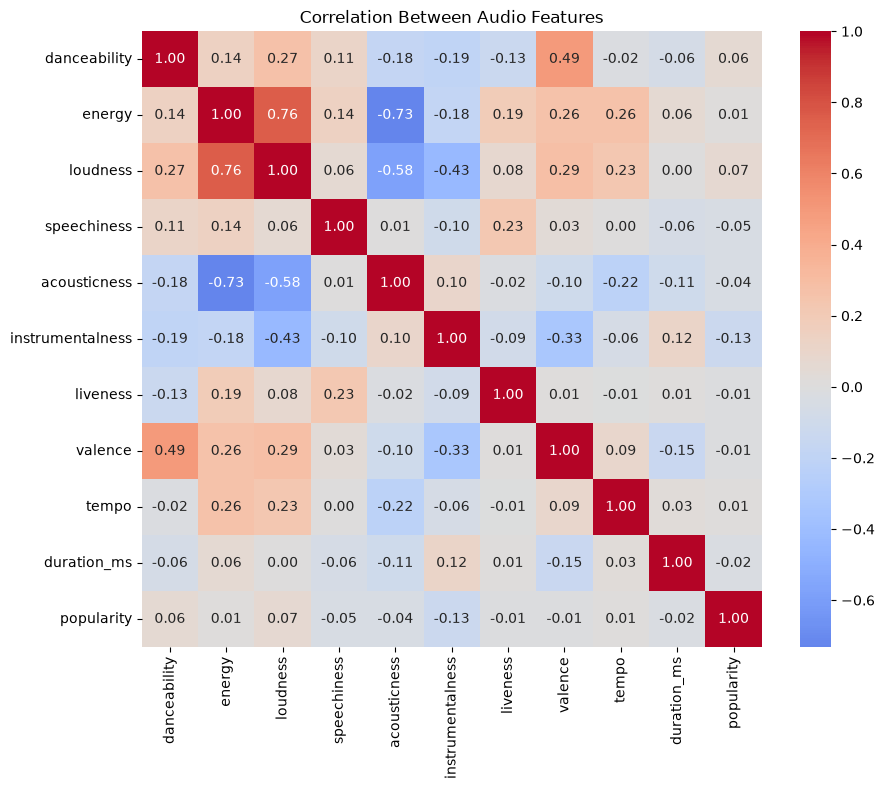

In [ ]:
audio_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms',
    'popularity'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[audio_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Audio Features")

plt.savefig(
    "../reports/figures/correlation_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Observation

- Energy and loudness show a strong positive correlation.
- Acousticness is negatively correlated with energy and loudness.
- Popularity has weak correlations with most audio features, suggesting that musical characteristics alone do not determine a song's popularity.

## 3. Audio Features Across Genres

Boxplots compare the distribution of different audio characteristics across popular music genres.

In [ ]:
top_genres = [
    'pop',
    'rock',
    'hip-hop',
    'classical',
    'edm',
    'jazz',
    'metal',
    'country'
]

subset = df[df["track_genre"].isin(top_genres)]


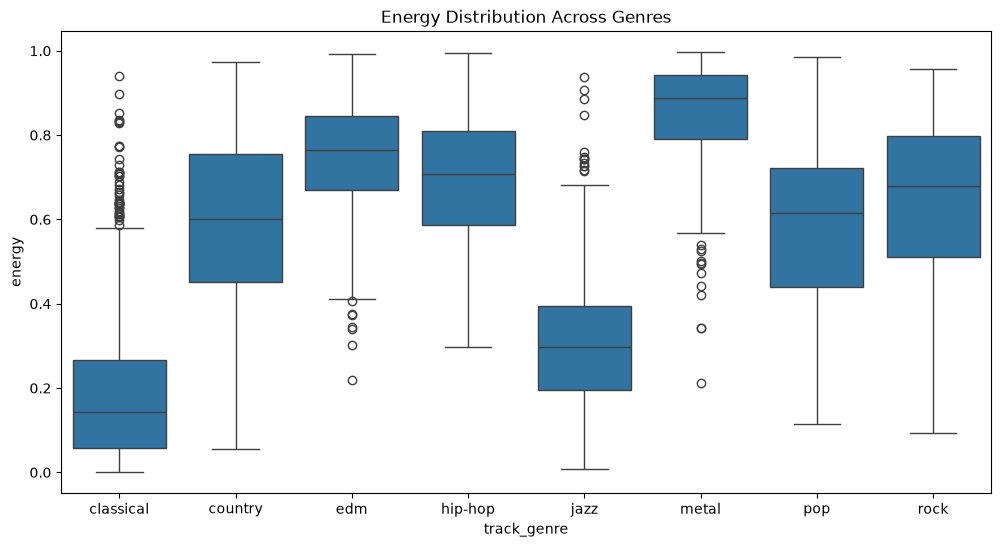

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=subset,
    x="track_genre",
    y="energy"
)

plt.title("Energy Distribution Across Genres")

plt.savefig(
    "../reports/figures/energy_by_genre.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


### Observation

Metal and EDM generally exhibit higher energy levels, while classical and jazz tracks tend to have lower energy.

### Danceability Distribution Across Genres

This boxplot compares the danceability of tracks across different music genres.


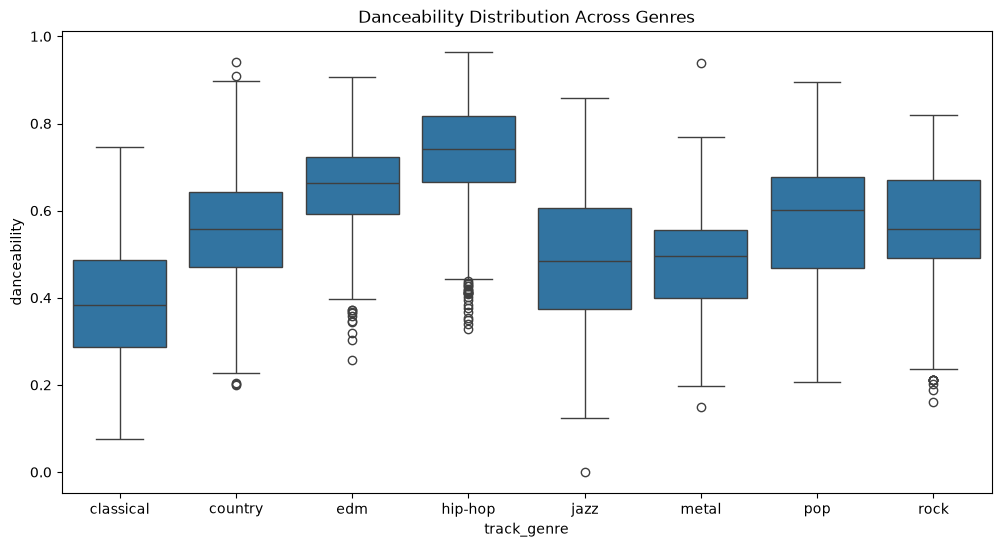

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=subset,
    x='track_genre',
    y='danceability'
)

plt.title('Danceability Distribution Across Genres')

plt.savefig(
    '../reports/figures/danceability_by_genre.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


**Observation**

- Pop and hip-hop generally exhibit higher danceability than genres such as classical and metal.
- This aligns with the intended purpose of these genres, as pop and hip-hop are often produced for dancing and mainstream audiences.

### Acousticness Distribution Across Genres

This boxplot compares the acousticness of tracks across different music genres.

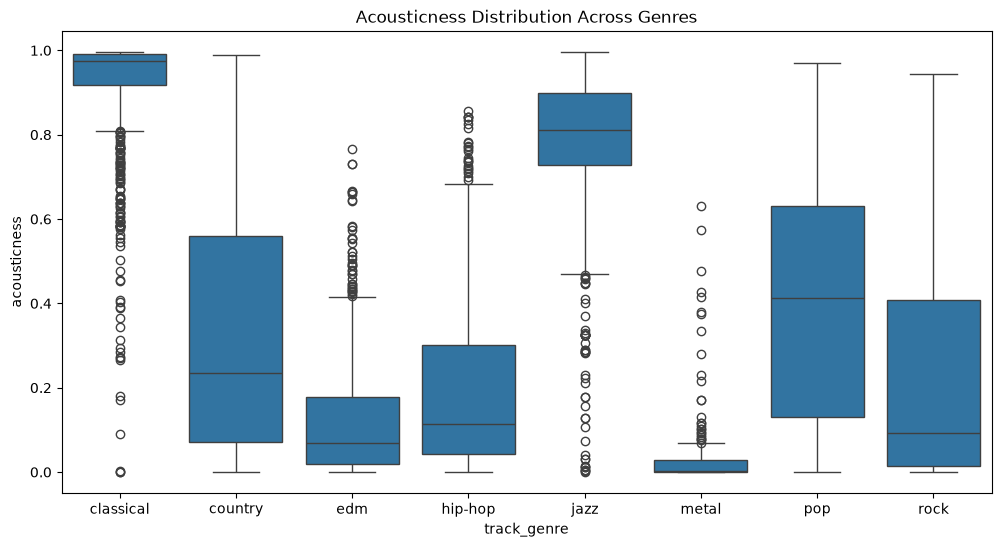

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=subset,
    x='track_genre',
    y='acousticness'
)

plt.title('Acousticness Distribution Across Genres')

plt.savefig(
    '../reports/figures/acousticness_by_genre.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


**Observation**

- Classical and jazz tracks generally have higher acousticness values.
- EDM and metal tend to have lower acousticness because they rely more heavily on electronic production techniques.

### Valence Distribution Across Genres

This boxplot compares the emotional positivity (valence) of tracks across different music genres.


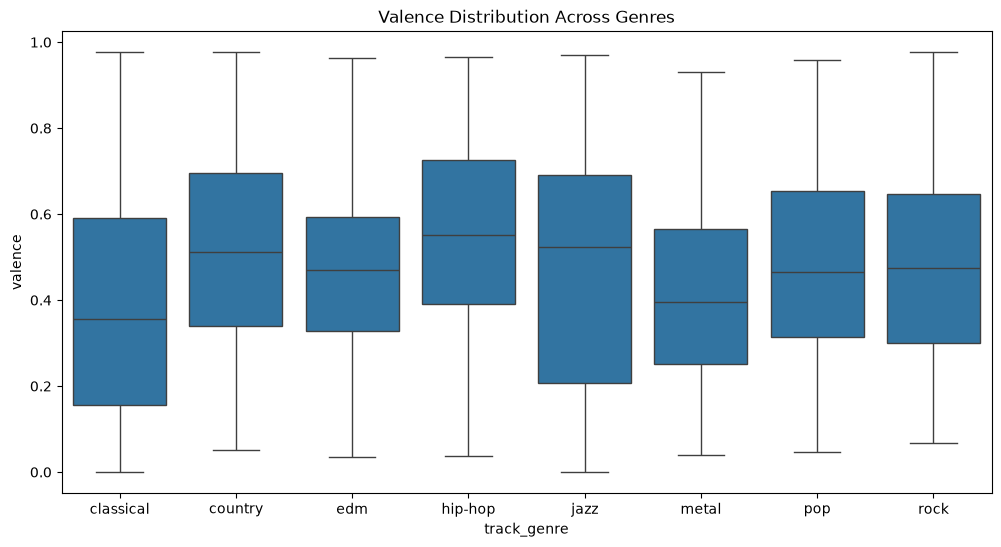

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=subset,
    x='track_genre',
    y='valence'
)

plt.title('Valence Distribution Across Genres')

plt.savefig(
    '../reports/figures/valence_by_genre.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

**Observation**

- Valence measures how positive or cheerful a song sounds.
- Different genres display varying distributions of valence, reflecting differences in mood and emotional expression.

## Top 15 Genres by Average Popularity

This visualization identifies the genres with the highest average popularity scores.


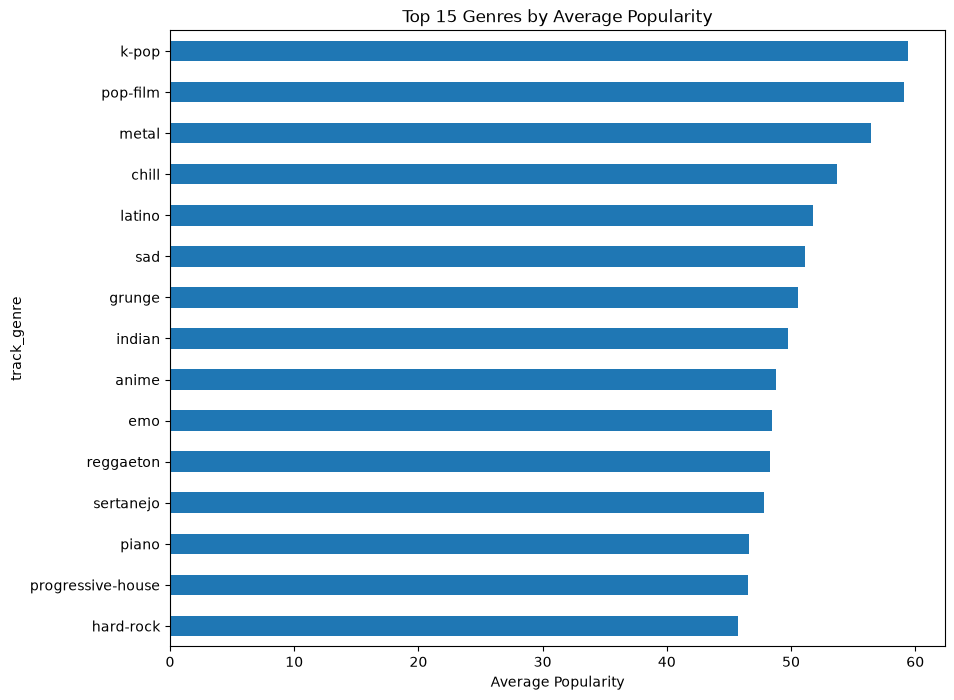

In [ ]:
genre_popularity = (
    df.groupby('track_genre')['popularity']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,8))

genre_popularity.head(15).plot(kind='barh')

plt.gca().invert_yaxis()

plt.title('Top 15 Genres by Average Popularity')

plt.xlabel('Average Popularity')

plt.savefig(
    '../reports/figures/top_genres_popularity.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

**Observation**

- Some genres consistently achieve higher average popularity than others.
- However, popularity is influenced by many factors beyond audio characteristics, such as artist recognition, marketing, release timing, and playlist placement.

## Popularity of Explicit vs Non-Explicit Tracks

This boxplot compares popularity scores between explicit and non-explicit songs.

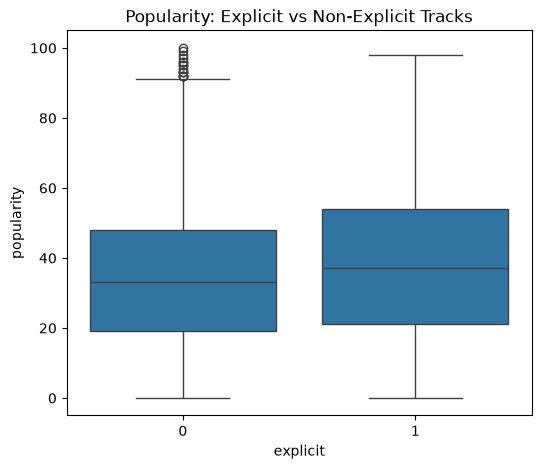

In [ ]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x='explicit',
    y='popularity'
)

plt.title('Popularity: Explicit vs Non-Explicit Tracks')

plt.savefig(
    '../reports/figures/explicit_popularity.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

**Observation**

- This comparison shows whether explicit songs tend to have higher popularity than non-explicit songs.
- While differences may exist, popularity is influenced by many other variables and should not be attributed solely to explicit content.

## Distribution of Musical Keys

This visualization shows how frequently each musical key appears in the dataset.

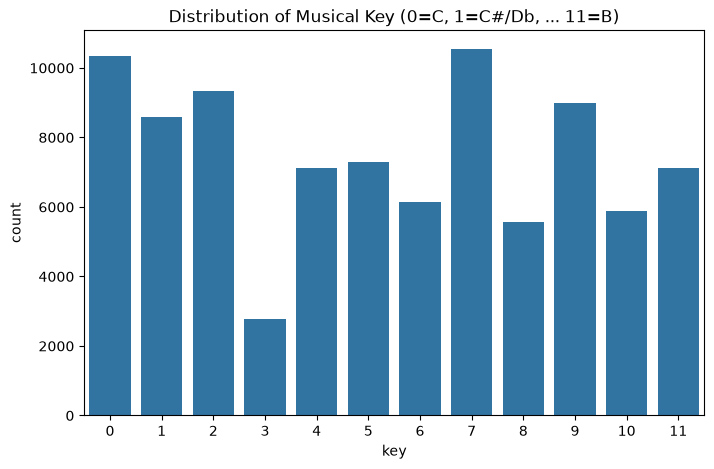

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='key'
)

plt.title('Distribution of Musical Key (0=C, 1=C#/Db, ... 11=B)')

plt.savefig(
    '../reports/figures/key_distribution.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

**Observation**

- Some musical keys appear more frequently than others in the dataset.
- Since musical key is a categorical feature rather than a continuous numerical variable, it should be interpreted accordingly during analysis.

# EDA Summary

The exploratory data analysis revealed several important patterns in the Spotify dataset:

- Track popularity is highly right-skewed, with many songs having low popularity and relatively few becoming highly popular.
- Energy and loudness exhibit a strong positive correlation, while acousticness is negatively correlated with energetic features.
- Popularity shows only weak correlations with individual audio features, indicating that factors beyond musical characteristics likely influence a track's success.
- Different genres display distinct distributions of energy, danceability, acousticness, and valence, highlighting stylistic differences.
- The frequency of musical keys is unevenly distributed, reinforcing that key should be treated as a categorical feature.

These findings provide valuable insights into the dataset and will help guide feature selection and model development in the next phase of the project.